Dataset Loaded Successfully
         Date      Open      High       Low     Close  Adj Close      Volume
0  1986-03-13  0.088542  0.101563  0.088542  0.097222   0.059827  1031788800
1  1986-03-14  0.097222  0.102431  0.097222  0.100694   0.061963   308160000
2  1986-03-17  0.100694  0.103299  0.100694  0.102431   0.063032   133171200
3  1986-03-18  0.102431  0.103299  0.098958  0.099826   0.061429    67766400
4  1986-03-19  0.099826  0.100694  0.097222  0.098090   0.060361    47894400

Dataset Cleaned Successfully


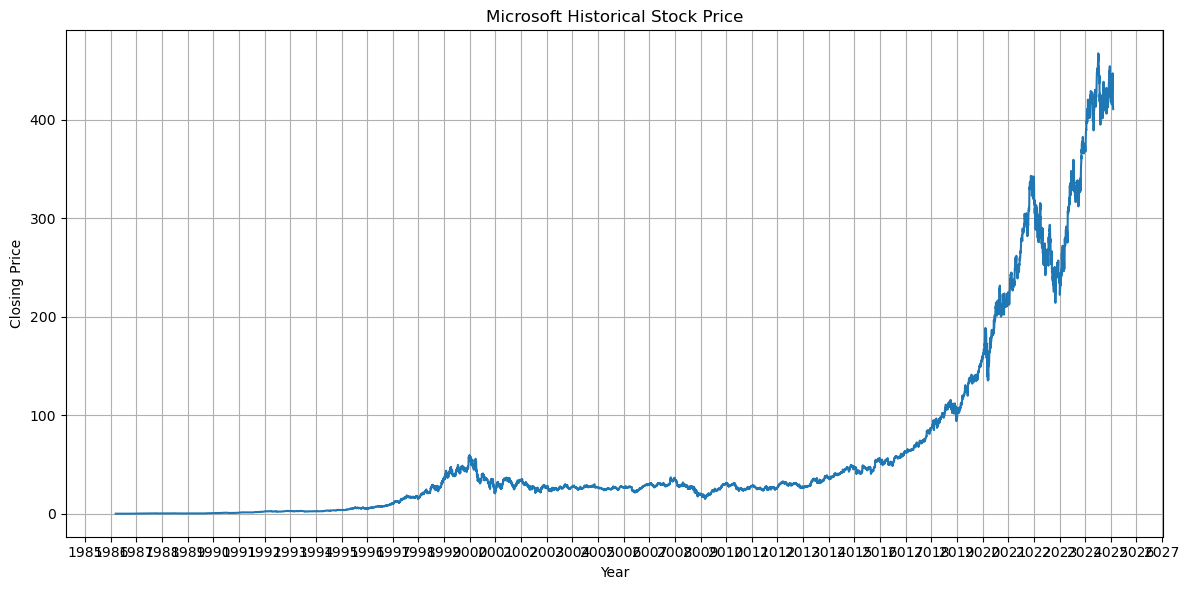


========== MODEL COMPARISON ==========
Linear Regression : 99.96 %
Random Forest     : 99.96 %
Decision Tree     : 99.93 %


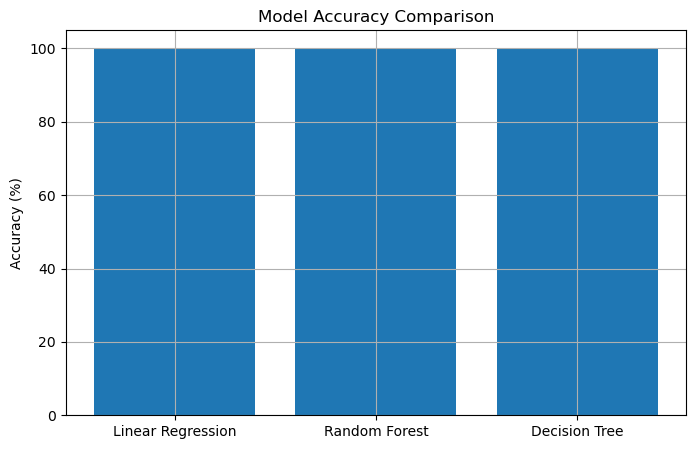


Best Model: Linear Regression

Predicted Next Day Stock Price:
415.58

Best Model Saved Successfully


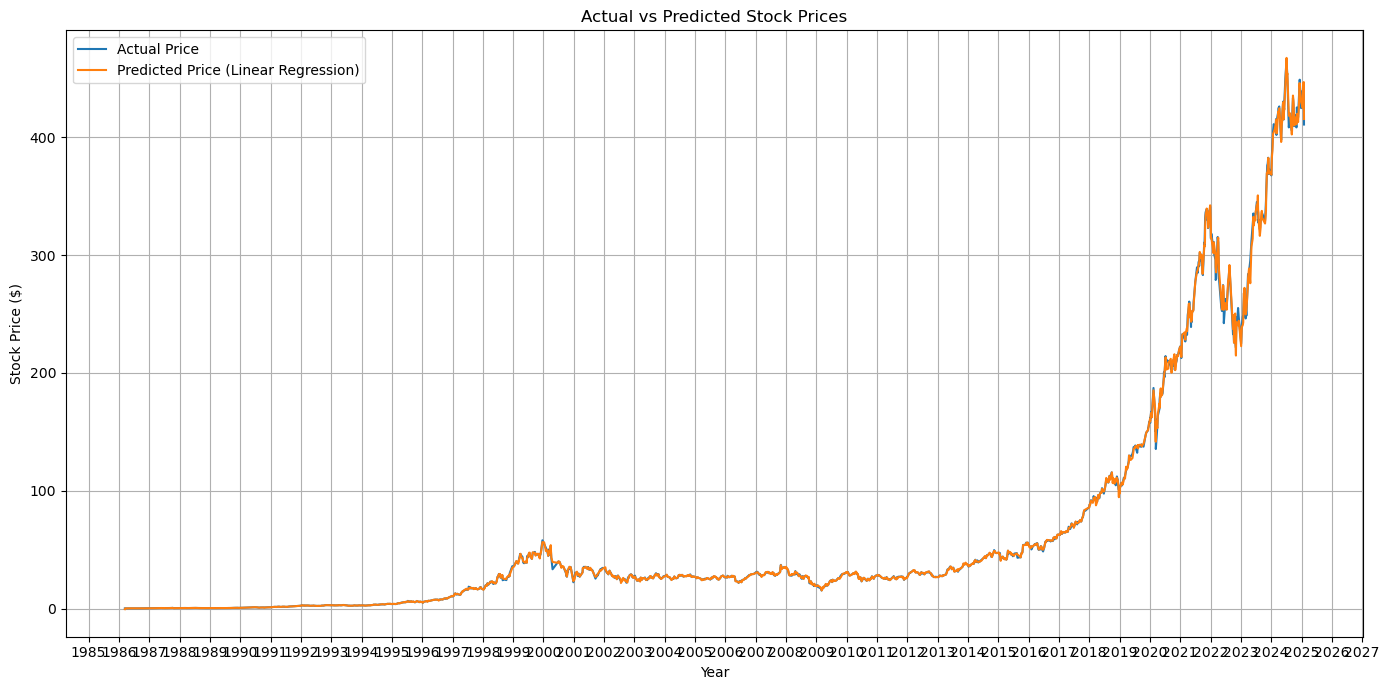


Project Completed Successfully


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pickle

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

# =====================================
# LOAD DATASET
# =====================================

file_path = r"C:\Users\techn\codec_ai_pro\microsoft_stock_data.csv"

df = pd.read_csv(file_path)

print("Dataset Loaded Successfully")
print(df.head())

# =====================================
# DATA CLEANING
# =====================================

df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

df['Date'] = pd.to_datetime(df['Date'])

df.sort_values('Date', inplace=True)
df.reset_index(drop=True, inplace=True)

print("\nDataset Cleaned Successfully")

# =====================================
# GRAPH 1 - HISTORICAL STOCK TREND
# =====================================

plt.figure(figsize=(12,6))

plt.plot(df['Date'], df['Close'])

plt.title("Microsoft Historical Stock Price")
plt.xlabel("Year")
plt.ylabel("Closing Price")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.grid(True)
plt.tight_layout()
plt.show()

# =====================================
# CREATE TARGET VARIABLE
# =====================================

df['Prediction'] = df['Close'].shift(-1)

df.dropna(inplace=True)

# =====================================
# FEATURES AND TARGET
# =====================================

X = df[['Open', 'High', 'Low', 'Close', 'Volume']]
y = df['Prediction']

# =====================================
# TRAIN TEST SPLIT
# =====================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =====================================
# LINEAR REGRESSION
# =====================================

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)
lr_accuracy = lr_model.score(X_test, y_test)

# =====================================
# RANDOM FOREST
# =====================================

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)
rf_accuracy = rf_model.score(X_test, y_test)

# =====================================
# DECISION TREE
# =====================================

dt_model = DecisionTreeRegressor(
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)
dt_accuracy = dt_model.score(X_test, y_test)

# =====================================
# MODEL COMPARISON
# =====================================

print("\n========== MODEL COMPARISON ==========")

print("Linear Regression :", round(lr_accuracy * 100, 2), "%")
print("Random Forest     :", round(rf_accuracy * 100, 2), "%")
print("Decision Tree     :", round(dt_accuracy * 100, 2), "%")

# =====================================
# GRAPH 2 - ACCURACY COMPARISON
# =====================================

models = [
    "Linear Regression",
    "Random Forest",
    "Decision Tree"
]

accuracies = [
    lr_accuracy * 100,
    rf_accuracy * 100,
    dt_accuracy * 100
]

plt.figure(figsize=(8,5))

plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")

plt.grid(True)

plt.show()

# =====================================
# FIND BEST MODEL
# =====================================

scores = {
    "Linear Regression": lr_accuracy,
    "Random Forest": rf_accuracy,
    "Decision Tree": dt_accuracy
}

best_model_name = max(scores, key=scores.get)

print("\nBest Model:", best_model_name)

# =====================================
# NEXT DAY PREDICTION
# =====================================

last_row = df[['Open', 'High', 'Low', 'Close', 'Volume']].iloc[-1:]

if best_model_name == "Linear Regression":
    next_price = lr_model.predict(last_row)[0]
    best_model = lr_model
    best_predictions = lr_predictions

elif best_model_name == "Random Forest":
    next_price = rf_model.predict(last_row)[0]
    best_model = rf_model
    best_predictions = rf_predictions

else:
    next_price = dt_model.predict(last_row)[0]
    best_model = dt_model
    best_predictions = dt_predictions

print("\nPredicted Next Day Stock Price:")
print(round(next_price, 2))

# =====================================
# SAVE BEST MODEL
# =====================================

with open("best_stock_model.pkl", "wb") as file:
    pickle.dump(best_model, file)

print("\nBest Model Saved Successfully")

# =====================================
# GRAPH 3 - ACTUAL VS PREDICTED
# =====================================

test_dates = df.loc[X_test.index, 'Date']

plot_df = pd.DataFrame({
    'Date': test_dates,
    'Actual': y_test,
    'Predicted': best_predictions
})

plot_df = plot_df.sort_values('Date')

plt.figure(figsize=(14,7))

plt.plot(
    plot_df['Date'],
    plot_df['Actual'],
    label='Actual Price'
)

plt.plot(
    plot_df['Date'],
    plot_df['Predicted'],
    label=f'Predicted Price ({best_model_name})'
)

ax = plt.gca()

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.title("Actual vs Predicted Stock Prices")

plt.xlabel("Year")
plt.ylabel("Stock Price ($)")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

print("\nProject Completed Successfully")